# JAX-ALFA Performance Benchmarks: NVIDIA A100 (80 GB)

*Last updated: May 2026*

This notebook reports wall-clock performance of JAX-ALFA across a range of cases,
grid resolutions, SGS models, and floating-point precisions.
All timings are expressed as **time per iteration (ms/iter)**, which normalizes by
the number of time steps in each completed run. This makes matched configurations
directly comparable, while cross-case comparisons should still be interpreted in
light of the active physics and configuration choices.

The notebook is structured around three questions:

1. **Resolution scaling** — how does cost grow with grid size?
2. **Precision impact** — how much does single precision (SP) accelerate runs vs. double (DP)?
3. **Model overhead** — what is the extra cost of LASDD vs. LAD, and WL vs. SM?

The data-loading cells scan `run.log` files automatically; adding a new platform
directory (e.g. `examples_A6000ada/`) and registering it in `PLATFORM_DIRS` below
is all that is needed to extend the plots to a new GPU.

## Hardware

| Platform label | System | GPU | VRAM |
| --- | --- | --- | --- |
| A100 (80 GB) | NVIDIA DGX Cloud | NVIDIA A100 Tensor Core GPU | 80 GB HBM2e |

## Case Summary

| Case | Type | Geostrophic wind | Surface BC | Moisture | Coriolis |
| --- | --- | --- | --- | --- | --- |
| CBL_N91 | Convective BL | $U_g = V_g = 0$ | Constant heat flux | No | Yes |
| SBL_GABLS1 | Stable BL | $U_g = 8$ m/s | Time-varying $T_s$ | No | Yes |

**SGS model naming convention**

| Label | Dynamic procedure | Base model | Scale assumption |
| --- | --- | --- | --- |
| LAD-SM | Locally Averaged Dynamic | Smagorinsky (SM) | Scale invariant |
| LAD-WL | Locally Averaged Dynamic | Wong-Lilly (WL) | Scale invariant |
| LASDD-SM | Locally Averaged Scale-Dependent Dynamic | Smagorinsky (SM) | Scale dependent |
| LASDD-WL | Locally Averaged Scale-Dependent Dynamic | Wong-Lilly (WL) | Scale dependent |

Run matrix for each case: resolutions $\times$ SGS models (LAD-SM, LAD-WL, LASDD-SM, LASDD-WL) $\times$ precisions (SP, DP).
Entries without a `run.log` were either not yet submitted or are still running.

## Setup

In [28]:
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

### Repository root and platform directories

In [29]:
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir = find_repo_root()
print(f'Repository root: {BaseDir}')

# Register platform directories here.
# Key = human-readable label shown in plots and tables.
# Value = path to the examples directory for that platform (relative to BaseDir).
PLATFORM_DIRS = {
    'A100 (80 GB)': BaseDir / 'examples',
    # 'RTX A6000 Ada': BaseDir / 'examples_A6000ada',   # uncomment when available
}

Repository root: /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1


### Data loading

In [30]:
_DIR_RE = re.compile(
    r'(?P<nx>\d+)x(?P<ny>\d+)x(?P<nz>\d+)'
    r'_(?P<dyn>LAD|LASDD)'
    r'_(?P<base>SM|WL)'
    r'_(?P<prec>SP|DP)$'
)
_TIME_RE = re.compile(r'Total Elapsed Time:\s+([\d.]+)\s+seconds')
_ITER_RE = re.compile(r'Finished Iteration\s+(\d+)\s*/\s*(\d+)')


def parse_run_log(log_path):
    """Return (total_seconds, total_iterations) from a run.log, or None.

    Some logs contain more than one completed timing block from repeated runs.
    Use the last Total Elapsed Time and last Finished Iteration entry, which
    correspond to the most recent completed block in the file.
    """
    text = log_path.read_text(errors='replace')
    all_times = _TIME_RE.findall(text)
    if not all_times:
        return None
    total_sec = float(all_times[-1])
    iters = _ITER_RE.findall(text)
    if not iters:
        return None
    last_done, last_total = int(iters[-1][0]), int(iters[-1][1])
    if last_done < last_total:
        return None  # incomplete run
    return total_sec, last_total


def scan_platform(examples_dir, platform_label):
    """Walk examples_dir and return a list of record dicts."""
    records = []
    for log_path in sorted(examples_dir.glob('*/runs/*/run.log')):
        run_dir  = log_path.parent
        run_name = run_dir.name
        case     = run_dir.parent.parent.name
        m = _DIR_RE.match(run_name)
        if not m:
            continue
        result = parse_run_log(log_path)
        if result is None:
            continue
        total_sec, total_iters = result
        nx        = int(m.group('nx'))
        dyn_key   = m.group('dyn')    # LAD | LASDD  (dynamic procedure)
        base_key  = m.group('base')   # SM  | WL     (base SGS model)
        prec_key  = m.group('prec')   # SP  | DP
        sgs_label = f"{dyn_key}-{base_key}"   # e.g. LAD-SM
        records.append({
            'Platform':         platform_label,
            'Case':             case,
            'Resolution':       f'{nx}³',
            'N':                nx,
            'Grid points':      nx**3,
            'Dynamic proc.':    dyn_key,
            'Base model':       base_key,
            'SGS model':        sgs_label,
            'Precision':        prec_key,
            'Total iterations': total_iters,
            'Total time (s)':   round(total_sec, 3),
            'Time/iter (ms)':   round(total_sec * 1000 / total_iters, 4),
        })
    return records


all_records = []
for label, path in PLATFORM_DIRS.items():
    if path.is_dir():
        recs = scan_platform(path, label)
        all_records.extend(recs)
        print(f'{label}: {len(recs)} completed runs found in {path}')
    else:
        print(f'{label}: directory not found — {path}')

df = pd.DataFrame(all_records)

sort_keys = ['Platform', 'Case', 'N', 'Dynamic proc.', 'Base model', 'Precision']
df_sorted = df.sort_values(sort_keys).reset_index(drop=True)

A100 (80 GB): 33 completed runs found in /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/examples


## Headline Metrics

A compact snapshot of the completed benchmark set before the detailed plots.

In [31]:
completed_runs = len(df_sorted)
completed_cases = df_sorted['Case'].nunique()
completed_resolutions = df_sorted[['Case', 'N']].drop_duplicates().shape[0]

headline = pd.DataFrame([
    {'Metric': 'Completed runs', 'Value': completed_runs},
    {'Metric': 'Cases with completed runs', 'Value': completed_cases},
    {'Metric': 'Case-resolution pairs', 'Value': completed_resolutions},
    {'Metric': 'Fastest run (ms/iter)', 'Value': df_sorted['Time/iter (ms)'].min()},
    {'Metric': 'Slowest run (ms/iter)', 'Value': df_sorted['Time/iter (ms)'].max()},
    {'Metric': 'Median run (ms/iter)', 'Value': df_sorted['Time/iter (ms)'].median()},
])

case_summary = (
    df_sorted
    .groupby(['Case', 'N', 'Resolution'], as_index=False)
    .agg(
        **{
            'Completed runs': ('Time/iter (ms)', 'size'),
            'Min ms/iter': ('Time/iter (ms)', 'min'),
            'Median ms/iter': ('Time/iter (ms)', 'median'),
            'Max ms/iter': ('Time/iter (ms)', 'max'),
        }
    )
    .sort_values(['Case', 'N'])
)

display(headline.style.hide(axis='index').format({'Value': '{:.4g}'}))
display(case_summary.style.hide(axis='index').format({
    'Min ms/iter': '{:.2f}',
    'Median ms/iter': '{:.2f}',
    'Max ms/iter': '{:.2f}',
}))

Metric,Value
Completed runs,33
Cases with completed runs,2
Case-resolution pairs,5
Fastest run (ms/iter),8.343
Slowest run (ms/iter),1028
Median run (ms/iter),34.9


Case,N,Resolution,Completed runs,Min ms/iter,Median ms/iter,Max ms/iter
CBL_N91,64,64³,8,11.27,15.01,18.74
CBL_N91,128,128³,8,42.05,70.11,101.56
CBL_N91,256,256³,7,481.15,509.35,1027.92
SBL_GABLS1,64,64³,8,8.34,12.26,16.69
SBL_GABLS1,128,128³,2,34.90,35.69,36.48


## Completion Matrix

Completed `run.log` coverage for the case-resolution combinations represented in the benchmark data. Blank cells indicate configurations with no completed timing in the scanned logs.

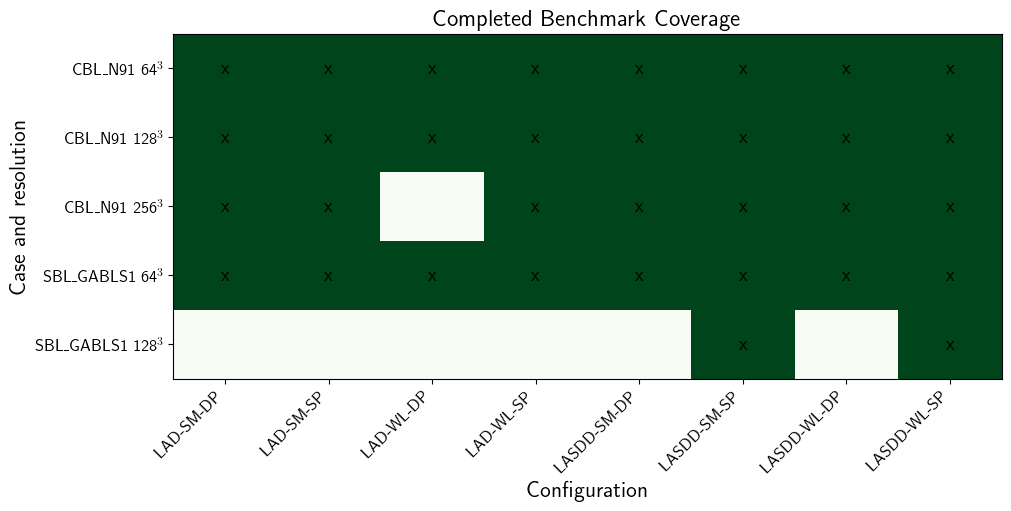

In [32]:
config_order = [
    f'{sgs}-{prec}'
    for sgs in ['LAD-SM', 'LAD-WL', 'LASDD-SM', 'LASDD-WL']
    for prec in ['DP', 'SP']
]

coverage = (
    df_sorted
    .assign(Config=df_sorted['SGS model'] + '-' + df_sorted['Precision'])
    .pivot_table(index=['Case', 'N'], columns='Config', values='Time/iter (ms)', aggfunc='size')
    .reindex(columns=config_order)
    .fillna(0)
    .astype(int)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 0.6 * len(coverage) + 2), constrained_layout=True)
complete = coverage.values > 0
escape_case = lambda s: s.replace('_', r'\_')
im = ax.imshow(complete, aspect='auto', cmap='Greens', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(coverage.columns)))
ax.set_xticklabels(coverage.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(coverage.index)))
ax.set_yticklabels([f'{escape_case(case)}  {n}$^3$' for case, n in coverage.index])

for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        ax.text(j, i, 'x' if complete[i, j] else '', ha='center', va='center', color='black')

ax.set_title('Completed Benchmark Coverage')
ax.set_xlabel('Configuration')
ax.set_ylabel('Case and resolution')
ax.grid(False)
plt.show()

## Compact Results Table

A summarized view of completed timings. The full per-run table remains available as `df_sorted` for audit or export.

In [33]:
compact_cols = ['Case', 'Resolution', 'Completed runs', 'Min ms/iter', 'Median ms/iter', 'Max ms/iter']

compact_results = case_summary[compact_cols].copy()
compact_results.style.hide(axis='index').format({
    'Min ms/iter': '{:.2f}',
    'Median ms/iter': '{:.2f}',
    'Max ms/iter': '{:.2f}',
})

Case,Resolution,Completed runs,Min ms/iter,Median ms/iter,Max ms/iter
CBL_N91,64³,8,11.27,15.01,18.74
CBL_N91,128³,8,42.05,70.11,101.56
CBL_N91,256³,7,481.15,509.35,1027.92
SBL_GABLS1,64³,8,8.34,12.26,16.69
SBL_GABLS1,128³,2,34.90,35.69,36.48


## Resolution Scaling

Time per iteration as a function of grid size $N$ for the CBL\_N91 case on A100 (80 GB).
Each panel shows one precision (DP left, SP right); lines are coloured by SGS model.
The dashed reference line shows ideal $N^3$ scaling anchored to the 64$^3$ DP average.

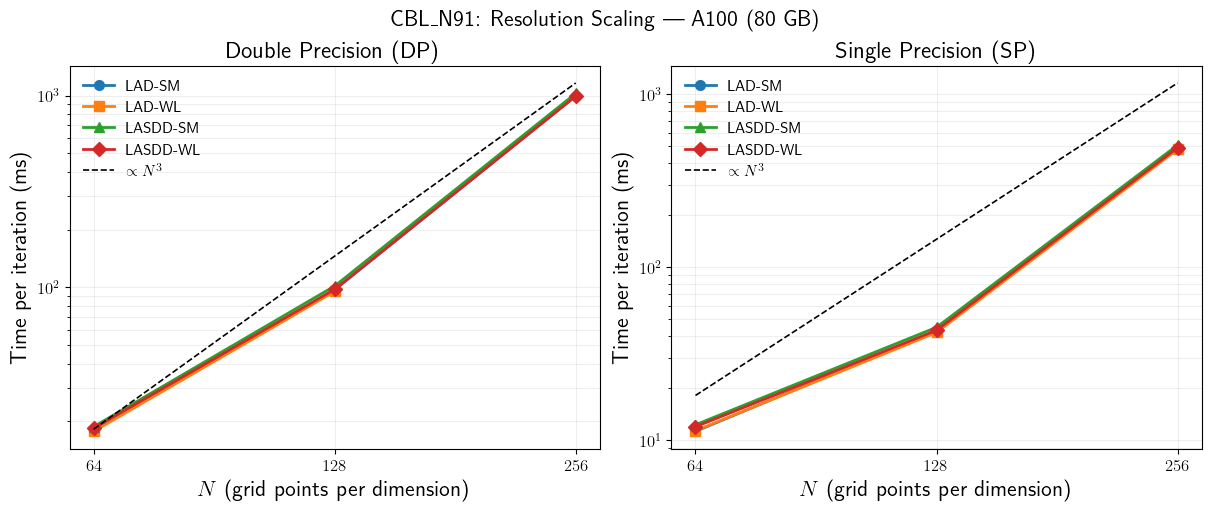

In [34]:
sgs_styles = {
    'LAD-SM':   {'color': '#1f77b4', 'marker': 'o'},
    'LAD-WL':   {'color': '#ff7f0e', 'marker': 's'},
    'LASDD-SM': {'color': '#2ca02c', 'marker': '^'},
    'LASDD-WL': {'color': '#d62728', 'marker': 'D'},
}

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, sharey=False)

for ax, prec, title in zip(axs, ['DP', 'SP'],
                            ['Double Precision (DP)', 'Single Precision (SP)']):
    sub = df_sorted[
        (df_sorted['Case'] == 'CBL_N91') &
        (df_sorted['Precision'] == prec) &
        (df_sorted['Platform'] == 'A100 (80 GB)')
    ].copy()

    for sgs_label, style in sgs_styles.items():
        grp = sub[sub['SGS model'] == sgs_label].sort_values('N')
        if grp.empty:
            continue
        ax.plot(grp['N'], grp['Time/iter (ms)'],
                color=style['color'], marker=style['marker'],
                linewidth=2, markersize=7, label=sgs_label)

    # N^3 reference line anchored at 64^3 DP average
    sub64_dp = df_sorted[
        (df_sorted['Case'] == 'CBL_N91') &
        (df_sorted['Precision'] == 'DP') &
        (df_sorted['N'] == 64) &
        (df_sorted['Platform'] == 'A100 (80 GB)')
    ]['Time/iter (ms)'].mean()
    N_ref = np.array([64, 128, 256])
    t_ref = sub64_dp * (N_ref / 64) ** 3
    ax.plot(N_ref, t_ref, 'k--', linewidth=1.2, label=r'$\propto N^3$')

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks([64, 128, 256])
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_xlabel(r'$N$ (grid points per dimension)')
    ax.set_ylabel(r'Time per iteration (ms)')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle(r'CBL\_N91: Resolution Scaling --- A100 (80 GB)', fontsize=16)
plt.show()

## Performance Ratio Summary

Three matched-pair diagnostics in one figure: SP speedup, LASDD dynamic-procedure overhead, and WL base-model overhead. Only completed matched pairs are shown.

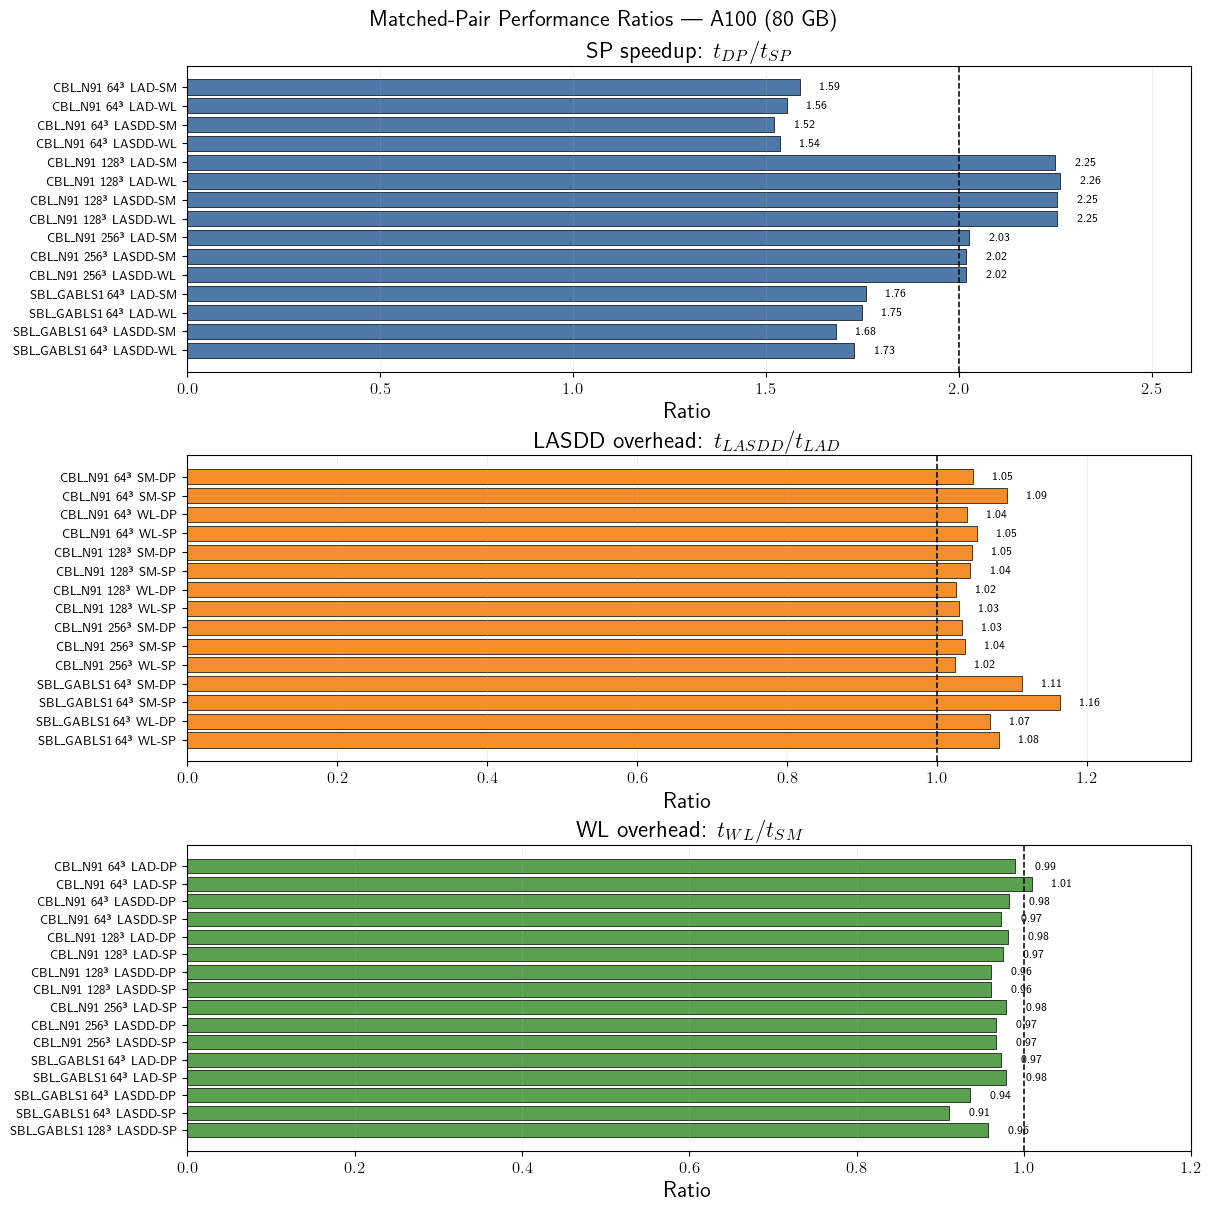

In [35]:
escape_case = lambda s: s.replace('_', r'\_')

merge_keys = ['Platform', 'Case', 'N', 'Dynamic proc.', 'Base model']

df_dp = df_sorted[df_sorted['Precision'] == 'DP'].copy()
df_sp = df_sorted[df_sorted['Precision'] == 'SP'].copy()

df_speedup = df_dp[merge_keys + ['SGS model', 'Time/iter (ms)', 'Resolution']].merge(
    df_sp[merge_keys + ['Time/iter (ms)']],
    on=merge_keys, suffixes=('_DP', '_SP')
)
df_speedup['Ratio'] = df_speedup['Time/iter (ms)_DP'] / df_speedup['Time/iter (ms)_SP']
df_speedup['Label'] = df_speedup.apply(
    lambda r: f"{escape_case(r['Case'])} {r['Resolution']} {r['SGS model']}", axis=1
)
df_speedup['Metric'] = 'SP speedup'

dyn_keys = ['Platform', 'Case', 'N', 'Base model', 'Precision', 'Resolution']
df_lad = df_sorted[df_sorted['Dynamic proc.'] == 'LAD'].copy()
df_lasdd = df_sorted[df_sorted['Dynamic proc.'] == 'LASDD'].copy()

df_dyn_ratio = df_lad[dyn_keys + ['Time/iter (ms)']].merge(
    df_lasdd[dyn_keys + ['Time/iter (ms)']],
    on=dyn_keys, suffixes=('_LAD', '_LASDD')
)
df_dyn_ratio['Ratio'] = df_dyn_ratio['Time/iter (ms)_LASDD'] / df_dyn_ratio['Time/iter (ms)_LAD']
df_dyn_ratio['Label'] = df_dyn_ratio.apply(
    lambda r: f"{escape_case(r['Case'])} {r['Resolution']} {r['Base model']}-{r['Precision']}", axis=1
)
df_dyn_ratio['Metric'] = 'LASDD/LAD overhead'

base_keys = ['Platform', 'Case', 'N', 'Dynamic proc.', 'Precision', 'Resolution']
df_sm = df_sorted[df_sorted['Base model'] == 'SM'].copy()
df_wl = df_sorted[df_sorted['Base model'] == 'WL'].copy()

df_base_ratio = df_sm[base_keys + ['Time/iter (ms)']].merge(
    df_wl[base_keys + ['Time/iter (ms)']],
    on=base_keys, suffixes=('_SM', '_WL')
)
df_base_ratio['Ratio'] = df_base_ratio['Time/iter (ms)_WL'] / df_base_ratio['Time/iter (ms)_SM']
df_base_ratio['Label'] = df_base_ratio.apply(
    lambda r: f"{escape_case(r['Case'])} {r['Resolution']} {r['Dynamic proc.']}-{r['Precision']}", axis=1
)
df_base_ratio['Metric'] = 'WL/SM overhead'

ratio_panels = [
    (df_speedup.sort_values(['Case', 'N', 'SGS model']), 'SP speedup: $t_{DP}/t_{SP}$', 2.0, '#4e79a7'),
    (df_dyn_ratio.sort_values(['Case', 'N', 'Base model', 'Precision']), 'LASDD overhead: $t_{LASDD}/t_{LAD}$', 1.0, '#f28e2b'),
    (df_base_ratio.sort_values(['Case', 'N', 'Dynamic proc.', 'Precision']), 'WL overhead: $t_{WL}/t_{SM}$', 1.0, '#59a14f'),
]

fig, axs = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

for ax, (sub, title, reference, color) in zip(axs, ratio_panels):
    y = np.arange(len(sub))
    ax.barh(y, sub['Ratio'], color=color, edgecolor='black', linewidth=0.5)
    ax.axvline(reference, color='k', linestyle='--', linewidth=1.1)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['Label'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Ratio')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
    xmax = max(sub['Ratio'].max() * 1.15, reference * 1.2)
    ax.set_xlim(0, xmax)
    for yi, value in zip(y, sub['Ratio']):
        ax.text(value + 0.02 * xmax, yi, f'{value:.2f}', va='center', fontsize=8)

fig.suptitle(r'Matched-Pair Performance Ratios --- A100 (80 GB)', fontsize=16)
plt.show()

## Cross-Case Diagnostic

Time per iteration at $64^3$ for the available completed runs. This is a diagnostic comparison rather than a normalized physics benchmark; differences can reflect active physics, configuration choices, and algorithmic work per solver iteration.

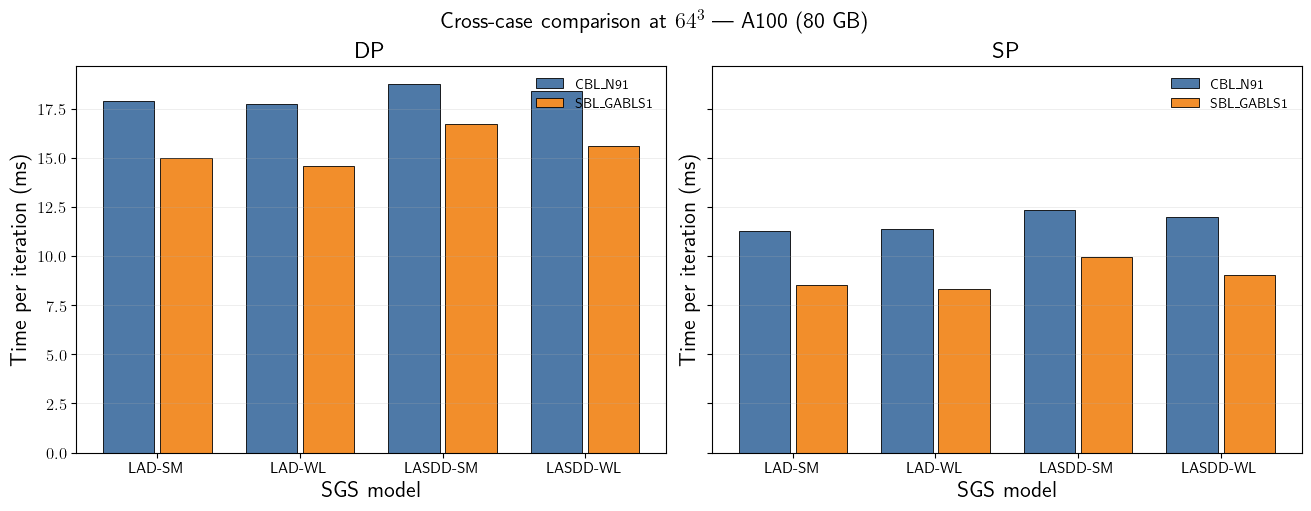

In [36]:
df_64 = df_sorted[
    (df_sorted['N'] == 64) &
    (df_sorted['Platform'] == 'A100 (80 GB)')
].copy()

sgs_models = sorted(df_64['SGS model'].unique())
cases = sorted(df_64['Case'].unique())

case_colors = {
    'CBL_N91':    '#4e79a7',
    'SBL_GABLS1': '#f28e2b',
    'NBL_A94':    '#59a14f',
    'DC_Wangara': '#e15759',
}

fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True, sharey=True)

for ax, prec in zip(axs, ['DP', 'SP']):
    sub = df_64[df_64['Precision'] == prec].sort_values(['Case', 'SGS model'])
    sgs_labels_avail = sorted(sub['SGS model'].unique())
    n_sgs = len(sgs_labels_avail)
    n_cases_avail = len(cases)
    group_width = 0.8
    bar_width = group_width / max(n_cases_avail, 1)

    x = np.arange(n_sgs)
    for i, case in enumerate(cases):
        vals = []
        for sgs in sgs_labels_avail:
            row = sub[(sub['Case'] == case) & (sub['SGS model'] == sgs)]
            vals.append(row['Time/iter (ms)'].values[0] if not row.empty else np.nan)
        offset = (i - n_cases_avail / 2 + 0.5) * bar_width
        ax.bar(x + offset, vals, width=bar_width * 0.9,
               color=case_colors.get(case, '#999'),
               edgecolor='black', linewidth=0.6, label=case.replace('_', r'\_'))

    ax.set_xticks(x)
    ax.set_xticklabels(sgs_labels_avail, fontsize=11)
    ax.set_xlabel('SGS model')
    ax.set_ylabel(r'Time per iteration (ms)')
    ax.set_title(f'{prec}')
    ax.legend(frameon=False, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(r'Cross-case comparison at $64^3$ --- A100 (80 GB)', fontsize=16)
plt.show()